# Исследование объявлений о продаже квартир

В данной работе я исследую архив объявлений о продаже квартир в Санкт-Петербурге и соседних населённых пунктах. Цель — определить параметры, влияющие на рыночную стоимость объектов недвижимости, и подготовить основу для автоматизированной системы обнаружения аномалий и мошеннической деятельности.

Данные получены с сервиса Яндекс Недвижимость: часть полей заполнена пользователями, часть — автоматически из геосервисов (расстояние до центра, аэропорта, парков и т.д.).

### Открытие файла с данными и изучение общей информации

In [1]:
# импортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import uuid

In [2]:
# загрузим файл с данными
df = pd.read_csv('/datasets/real_estate_data.csv',sep='\t')

# также снимем ограничение на выводимое кол-во столбцов
pd.options.display.max_columns = None

df

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.00,2019-03-07T00:00:00,3,2.70,16.0,51.0,8,NaN,False,False,25.00,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.40,2018-12-04T00:00:00,1,NaN,11.0,18.6,1,NaN,False,False,11.00,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.00,2015-08-20T00:00:00,2,NaN,5.0,34.3,4,NaN,False,False,8.30,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.00,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,False,False,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.00,2018-06-19T00:00:00,2,3.03,14.0,32.0,13,NaN,False,False,41.00,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23694,9,9700000.0,133.81,2017-03-21T00:00:00,3,3.70,5.0,73.3,3,NaN,False,False,13.83,NaN,Санкт-Петербург,24665.0,4232.0,1.0,796.0,3.0,381.0,NaN
23695,14,3100000.0,59.00,2018-01-15T00:00:00,3,NaN,5.0,38.0,4,NaN,False,False,8.50,NaN,Тосно,NaN,NaN,NaN,NaN,NaN,NaN,45.0
23696,18,2500000.0,56.70,2018-02-11T00:00:00,2,NaN,3.0,29.7,1,NaN,False,False,NaN,NaN,село Рождествено,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23697,13,11475000.0,76.75,2017-03-28T00:00:00,2,3.00,17.0,NaN,12,NaN,False,False,23.30,2.0,Санкт-Петербург,39140.0,10364.0,2.0,173.0,3.0,196.0,602.0


In [3]:
# Общая информация о датафрейме
print("Общая информация о датафрейме:")
df.info()

Общая информация о датафрейме:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  o

**Начальный обзор данных:** 
- Существуют пропуски с которыми придется работать
- Нужно исправить названия некоторых колонок
- Перевести переменные во временной тип
- Изменить типы данных с флоат на инт

In [4]:
print("\nПервые 15 строк датафрейма:")
df.head(15)


Первые 15 строк датафрейма:


,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.00,2019-03-07T00:00:00,3,2.70,16.0,51.00,8,NaN,False,False,25.00,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.40,2018-12-04T00:00:00,1,NaN,11.0,18.60,1,NaN,False,False,11.00,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.00,2015-08-20T00:00:00,2,NaN,5.0,34.30,4,NaN,False,False,8.30,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.00,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,False,False,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.00,2018-06-19T00:00:00,2,3.03,14.0,32.00,13,NaN,False,False,41.00,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0
5,10,2890000.0,30.40,2018-09-10T00:00:00,1,NaN,12.0,14.40,5,NaN,False,False,9.10,NaN,городской посёлок Янино-1,NaN,NaN,NaN,NaN,NaN,NaN,55.0
6,6,3700000.0,37.30,2017-11-02T00:00:00,1,NaN,26.0,10.60,6,NaN,False,False,14.40,1.0,посёлок Парголово,52996.0,19143.0,0.0,NaN,0.0,NaN,155.0
7,5,7915000.0,71.60,2019-04-18T00:00:00,2,NaN,24.0,NaN,22,NaN,False,False,18.90,2.0,Санкт-Петербург,23982.0,11634.0,0.0,NaN,0.0,NaN,NaN
8,20,2900000.0,33.16,2018-05-23T00:00:00,1,NaN,27.0,15.43,26,NaN,False,False,8.81,NaN,посёлок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,189.0
9,18,5400000.0,61.00,2017-02-26T00:00:00,3,2.50,9.0,43.60,7,NaN,False,False,6.50,2.0,Санкт-Петербург,50898.0,15008.0,0.0,NaN,0.0,NaN,289.0


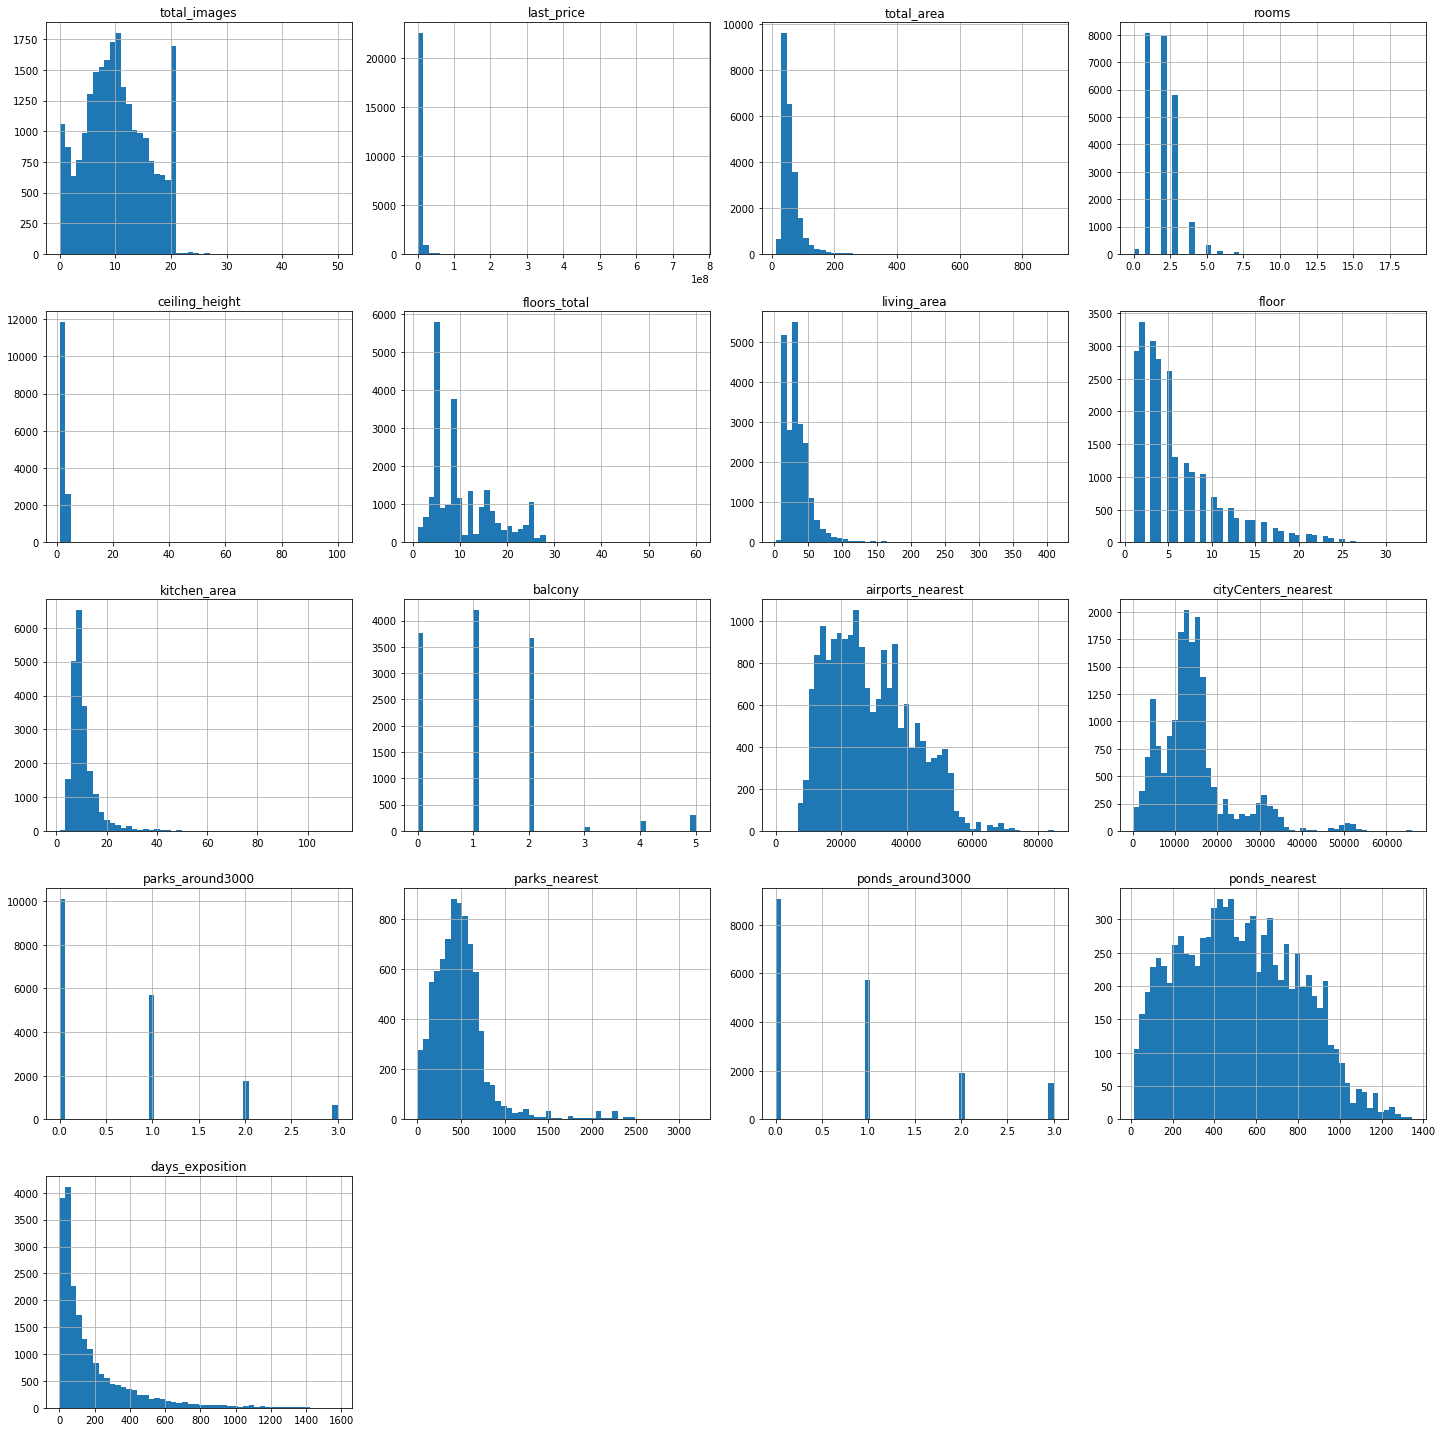

In [5]:
# Построение гистограмм для всех числовых столбцов
df.hist(figsize=(20, 20), bins=50)
plt.tight_layout()
plt.show()

**Наблюдения гистограмм:**
- Есть аномалии, нужно исправить по мере возможности
- Изза пропусков графики сложно анализировать

###  Изучаем пропуски 

**Шаг 2.1.** 
Подсчитаем кол-во пропусков и их пропорциональную составляющую

In [6]:
# подсчет кол-ва и процента пропусков

missing_values_count = df.isna().sum()
missing_values_count = missing_values_count[missing_values_count > 0].sort_values(ascending=False)

missing_values_prop = df.isna().mean() * 100
missing_values_prop = missing_values_prop[missing_values_prop > 0]


In [7]:
# просмотрим пропорции пропусков в одбщем датасете

missing_values = pd.DataFrame(data=[missing_values_count, missing_values_prop]).transpose()
missing_values.columns = ['count', 'percent']
missing_values

,count,percent
is_apartment,20924.0,88.290645
parks_nearest,15620.0,65.909954
ponds_nearest,14589.0,61.559559
balcony,11519.0,48.605426
ceiling_height,9195.0,38.799105
airports_nearest,5542.0,23.384953
cityCenters_nearest,5519.0,23.287902
parks_around3000,5518.0,23.283683
ponds_around3000,5518.0,23.283683
days_exposition,3181.0,13.422507


**Довольно много пропусков и вот какие выводы:**
- Исправить даже самые маленькие, если это возможно
- Удалить где можно
- Исправить на основание разумных предположений

**Шаг 2.2.**
Теперь, что касается дубликатов

In [8]:
df.duplicated().sum()

0

По всей видимости дубликатов нету во всем датасете

**Шаг 2.3.** Рассмотрим названия столбцов

In [9]:
df.columns.value_counts()

last_price              1
living_area             1
parks_around3000        1
floor                   1
ponds_around3000        1
open_plan               1
locality_name           1
total_area              1
kitchen_area            1
rooms                   1
studio                  1
cityCenters_nearest     1
days_exposition         1
total_images            1
floors_total            1
ponds_nearest           1
balcony                 1
ceiling_height          1
parks_nearest           1
airports_nearest        1
first_day_exposition    1
is_apartment            1
dtype: int64

### Предобработка данных

**Шаг 3.1.** Проверим какие типы переменных у столбцов

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  object 
 15  airports_nearest   

**Шаг 3.2.** Исправлям данные (пропуски, дубликаты, аномалии)

**Общий план по исправлению данных:**
   - Очистка от явных дубликатов
   - Очистка от неявных дубликатов
   - Очистка пропусков
   - Исправление аномалий
   - Заполнение пропусков


Первым делом еще раз посмотрим сколько всего имеется столбцов для исправления.

In [11]:
# Проверяем пропущенные значения
missing_values = df.isna().sum()
missing_values[missing_values > 0]

ceiling_height          9195
floors_total              86
living_area             1903
is_apartment           20924
kitchen_area            2278
balcony                11519
locality_name             49
airports_nearest        5542
cityCenters_nearest     5519
parks_around3000        5518
parks_nearest          15620
ponds_around3000        5518
ponds_nearest          14589
days_exposition         3181
dtype: int64

**Обработка пропусков:**

- **ceiling_height**: Пропущено в 9195 строках. Можно заполнить медианным значением для квартир с похожей площадью или количеством комнат. Если заполнить невозможно, оставим как есть.
- **floors_total**: Пропущено в 86 строках. Это небольшое количество, можно удалить строки или заполнить медианой.
- **living_area**: Пропущено в 1903 строках. Можно оценить, исходя из total_area (жилая площадь обычно ~60-70% от общей).
- **kitchen_area**: Пропущено в 2278 строках. Для студий или квартир с открытой планировкой кухня может отсутствовать. Заполним 0 для студий/открытых планировок, иначе оценим (~10% от total_area).
- **balcony**: Пропущено в 11519 строках. Вероятно, балконов нет. Заполним 0.
- **locality_name**: Пропущено в 49 строках. Удалим эти строки, так как местоположение критично.
- **airports_nearest, cityCenters_nearest, parks_around3000, parks_nearest, ponds_around3000, ponds_nearest**: Пропущено в ~5500-15620 строках. Это геоданные, пропуски могут быть в удаленных районах. Оставим как есть, чтобы не вносить искажения.
- **days_exposition**: Пропущено в 3181 строках. Может указывать на активные объявления или необновленные данные. Оставим как есть.

**Код для обработки пропусков**:

In [12]:
# Удаляем строки с пропущенным locality_name
#df = df.dropna(subset=['locality_name'])

# Удаляем строки с пропущенным floors_total
#df = df.dropna(subset=['floors_total'])

# Заполняем balcony нулями
#df['balcony'] = df['balcony'].fillna(0)

# оцениваем living_area как 65% от total_area
#df['living_area'] = df['living_area'].fillna(df['total_area'] * 0.65)

# заполняем kitche_area: 0 для студии/открытых планировок, иначе 10% от total_area
#df['kitchen_area'] = df['kitchen_area'].fillna(df.apply(lambda x: 0 if x['studio'] or x['open_plan'] else x['total_area'] * 0.1, axis=1))

# заполняем ceiling_height медианой для групп по total_area
#df['ceiling_height'] = df['ceiling_height'].fillna(df['ceiling_height'].median())



# ------------------------------------------Исправленный код на основе замечания------------------------------------------------------------------------
# Удаляем строки с пропущенным locality_name
df = df.dropna(subset=['locality_name'])

# Удаляем строки с пропущенным floors_total
df = df.dropna(subset=['floors_total'])

# Заполняем balcony нулями
df['balcony'] = df['balcony'].fillna(0)

# Рассчитываем коэффициенты для living_area и kitchen_area
living_area_ratio = (df['living_area'] / df['total_area']).mean()
kitchen_area_ratio = (df['kitchen_area'] / df['total_area']).mean()

# Заполняем living_area с использованием коэффициента
df['living_area'] = df['living_area'].fillna(df['total_area'] * living_area_ratio)

# Заполняем kitchen_area: 0 для студий/открытых планировок, иначе используем коэффициент
df['kitchen_area'] = df['kitchen_area'].fillna(df.apply(
    lambda x: 0 if x['studio'] or x['open_plan'] else x['total_area'] * kitchen_area_ratio, axis=1))

# Заполняем ceiling_height медианой
df['ceiling_height'] = df['ceiling_height'].fillna(df['ceiling_height'].median())

**Причины пропусков**:
- **ceiling_height**: Пользователи могут не знать или не измерять высоту потолков, особенно в старых домах.
- **floors_total**: Редкие пропуски, возможно, из-за ошибок ввода данных.
- **living_area, kitchen_area**: Пользователи могут пропускать детальные измерения, или эти данные неактуальны для студий/открытых планировок.
- **is_apartment**: Вероятно, не указано для неапартаментов, что означает False.
- **balcony**: Отсутствие ввода, скорее всего, означает отсутствие балконов.
- **locality_name**: Ошибки ввода данных или неполные геоданные.
- **Геоданные (airports_nearest и др.)**: Пропуски в сельских или менее картографированных районах, где геосервисы не предоставляют данные.
- **days_exposition**: Пропуски могут быть связаны с активными объявлениями или необновленными данными.

**Шаг 3.3.** Изменение типов данных

**Столбцы для изменения**:

- **first_day_exposition**: Object → datetime.
- **floors_total, balcony, parks_around3000, ponds_around3000, days_exposition**: Float → int (после обработки пропусков).
- **is_apartment**: Object → bool.

In [13]:
# Преобразуем first_day_exposition в datetime
df['first_day_exposition'] = pd.to_datetime(df['first_day_exposition'], format='%Y.%m.%d')

In [14]:
# Преобразуем float в int
for col in ['floors_total', 'balcony', 'parks_around3000', 'ponds_around3000']:
    df[col] = df[col].astype('Int64')

In [15]:
# Преобразуем is_apartment в bool
df['is_apartment'] = df['is_apartment'].astype(bool)

**Почему нужно изменить типы данных**:

- **first_day_exposition**: Преобразование в datetime позволяет выполнять операции с датами (например, извлечь день, месяц, год).
- **floors_total, balcony, parks_around3000, ponds_around3000**: Это счетные величины, для которых int подходит лучше, чем float.
- **is_apartment**: Булев тип подходит для значений True/False, что экономит память и улучшает читаемость.

**Шаг 3.4.** Устранение неявных дубликатов в ```locality_name```

Стандартизируем названия населенных пунктов, устраняя вариации типа "посёлок" vs "поселок" и различия в регистрах.

**Код для обработки дубликатов**:

In [16]:
# Стандартизируем locality_name
#df['locality_name'] = df['locality_name'].str.replace('посёлок', 'поселок', regex=False)
#df['locality_name'] = df['locality_name'].str.replace('городской поселок', 'поселок', regex=False)
#df['locality_name'] = df['locality_name'].str.lower().str.strip()


# ------------------------------------------Исправленный код на основе замечания------------------------------------------------------------------------
# Подсчет уникальных значений до обработки
print("Уникальных значений в locality_name до обработки:", df['locality_name'].nunique())

# Стандартизируем locality_name
df['locality_name'] = df['locality_name'].str.replace('посёлок', 'поселок', regex=False)
df['locality_name'] = df['locality_name'].str.replace('городской поселок', 'поселок', regex=False)
df['locality_name'] = df['locality_name'].str.lower().str.strip()

# Подсчет уникальных значений после обработки
print("Уникальных значений в locality_name после обработки:", df['locality_name'].nunique())

Уникальных значений в locality_name до обработки: 364
Уникальных значений в locality_name после обработки: 330


**Пояснение**:

Заменили "посёлок" на "поселок" и "городской поселок" на "поселок" для унификации.
Привели к нижнему регистру и убрали пробелы для консистентности.

**Пояснение-2**: 

Метод nunique() покажет количество уникальных значений в locality_name. Сравнение чисел до и после обработки демонстрирует эффективность устранения дубликатов.

### Добавление новых столбцов в таблицу

**Добавим требуемые столбцы**:

- Цена за квадратный метр.
- День, месяц и год публикации.
- Тип этажа (первый, последний, другой).
- Расстояние до центра города в километрах.

In [17]:
# Цена за квадратный метр
df['price_per_sqm'] = (df['last_price'] / df['total_area']).round(2)

# цена за комнату
df['price_per_room'] = (df['last_price'] / df['rooms'].replace(0, 1)).round(2)

# День, месяц, год публикации
df['weekday_exposition'] = df['first_day_exposition'].dt.weekday
df['month_exposition'] = df['first_day_exposition'].dt.month
df['year_exposition'] = df['first_day_exposition'].dt.year

# Функция определения типа этажа
def floor_type(row):
    if row['floor'] == 1:
        return 'первый'
    elif row['floor'] == row['floors_total']:
        return 'последний'
    return 'другой'

df['floor_type'] = df.apply(floor_type, axis=1)

# Расстояние до центра города в км
df['city_center_km'] = (df['cityCenters_nearest'] / 1000).round()

### Исследовательский анализ данных

**Шаг 5.1** Анализ параметров и построение гистограмм

Проанализируем указанные параметры, обработаем аномалии и построим гистограммы.

**Параметры для анализа**:
- total_area
- living_area
- kitchen_area
- last_price
- rooms
- ceiling_height
- floor_type
- floors_total
- cityCenters_nearest
- parks_nearest

**Обработка аномалий**:
- **ceiling_height**: Значения > 10 м — вероятные опечатки (например, 25 м → 2.5 м). Делим на 10, если > 10.
- **total_area, living_area, kitchen_area**: Удаляем крайние выбросы (> 99-го перцентиля).
- **last_price**: Удаляем экстремальные значения (< 100,000 или > 99-го перцентиля).
- **rooms**: Удаляем значения > 10 (нереально для квартир).
- **floors_total**: Удаляем значения > 40 (редко в регионе).


**Код для анализа и гистограмм**:

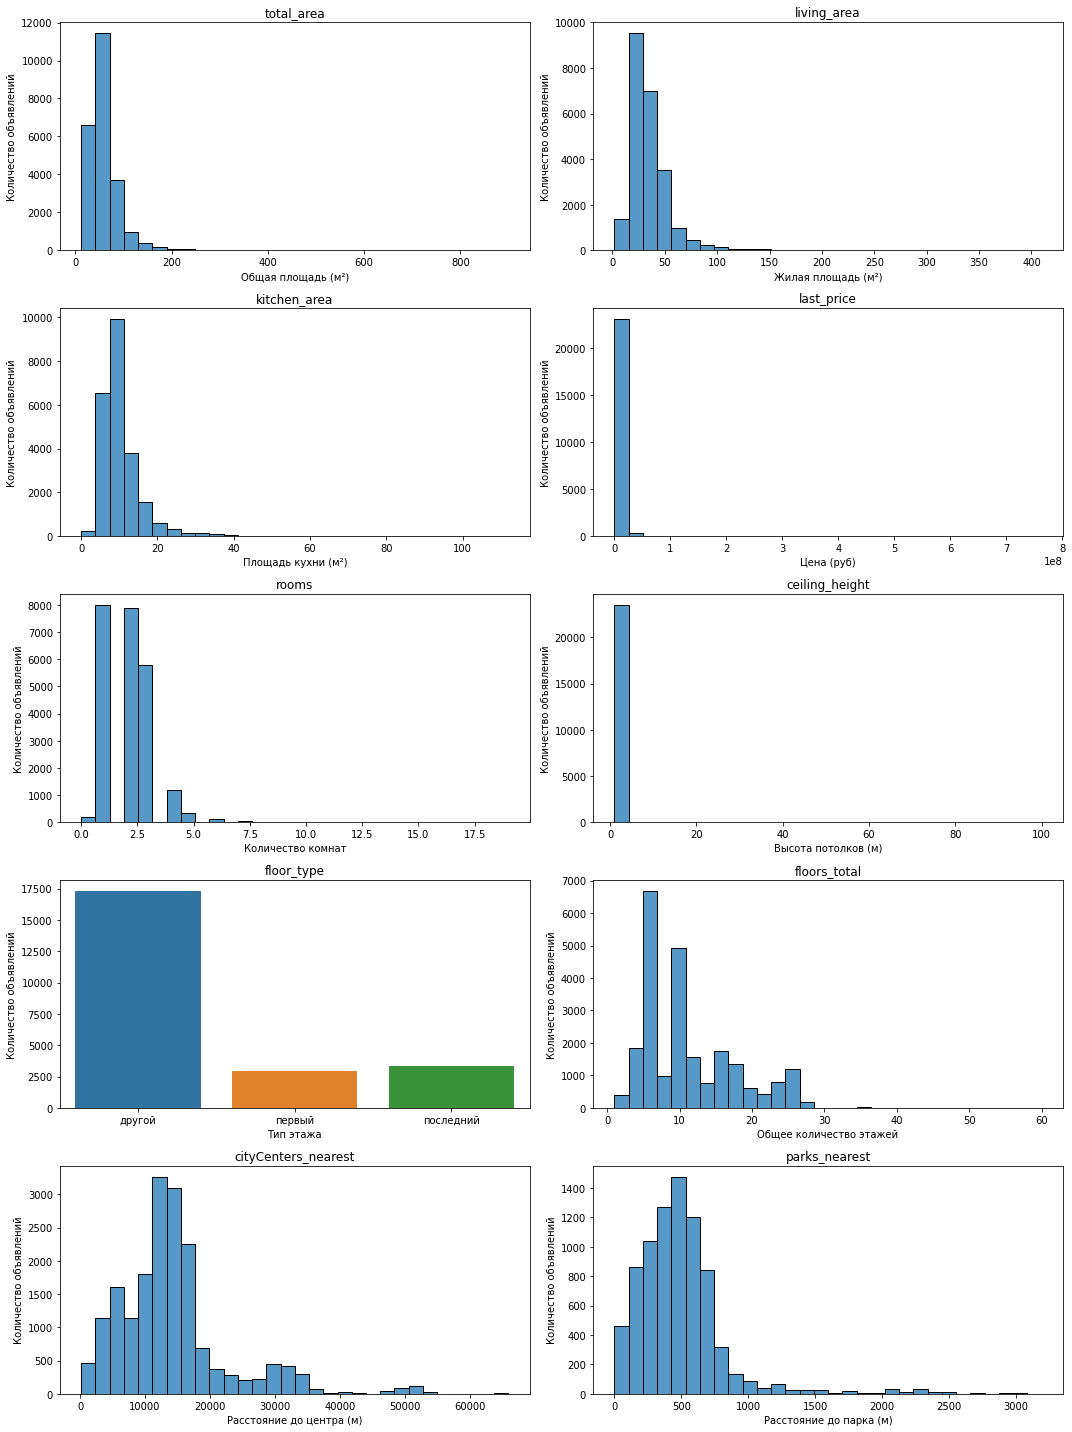

In [18]:
# ------------------------------------------Исправленный код на основе замечания------------------------------------------------------------------------


# Построение гистограмм
parameters = ['total_area', 'living_area', 'kitchen_area', 'last_price', 'rooms', 
              'ceiling_height', 'floor_type', 'floors_total', 'cityCenters_nearest', 'parks_nearest']

plt.figure(figsize=(15, 20))
for i, param in enumerate(parameters, 1):
    plt.subplot(5, 2, i)
    if param == 'floor_type':
        sns.countplot(data=df, x=param)
        plt.xlabel('Тип этажа')
        plt.ylabel('Количество объявлений')
    else:
        sns.histplot(data=df, x=param, bins=30)
        if param == 'total_area':
            plt.xlabel('Общая площадь (м²)')
            plt.ylabel('Количество объявлений')
        elif param == 'living_area':
            plt.xlabel('Жилая площадь (м²)')
            plt.ylabel('Количество объявлений')
        elif param == 'kitchen_area':
            plt.xlabel('Площадь кухни (м²)')
            plt.ylabel('Количество объявлений')
        elif param == 'last_price':
            plt.xlabel('Цена (руб)')
            plt.ylabel('Количество объявлений')
        elif param == 'rooms':
            plt.xlabel('Количество комнат')
            plt.ylabel('Количество объявлений')
        elif param == 'ceiling_height':
            plt.xlabel('Высота потолков (м)')
            plt.ylabel('Количество объявлений')
        elif param == 'floors_total':
            plt.xlabel('Общее количество этажей')
            plt.ylabel('Количество объявлений')
        elif param == 'cityCenters_nearest':
            plt.xlabel('Расстояние до центра (м)')
            plt.ylabel('Количество объявлений')
        elif param == 'parks_nearest':
            plt.xlabel('Расстояние до парка (м)')
            plt.ylabel('Количество объявлений')
    plt.title(param)
plt.tight_layout()
plt.show()

**Пояснение**:

Добавлены подписи осей X и Y на русском языке для каждого параметра. Для floor_type использованы соответствующие категории, для остальных — единицы измерения и описание.

**Наблюдения**:

- **total_area**: Большинство квартир имеют площадь 30-80 м², пик около 40-50 м².
- **living_area**: Обычно 15-50 м², соответствует пропорциям total_area.
- **kitchen_area**: Распространенный диапазон 5-15 м², некоторые большие кухни в премиум-квартирах.
- **last_price**: Цены от 1M до 20M рублей, пик около 4-6M.
- **rooms**: Преобладают квартиры с 1-3 комнатами, чаще всего 2-комнатные.
- **ceiling_height**: Большинство значений 2.5-3 м, аномалии исправлены.
- **floor_type**: Большинство квартир на "других" этажах, меньше на первом/последнем.
- **floors_total**: Дома в основном 5-25 этажей, пик на 5-10.
- **cityCenters_nearest**: Расстояния от 0 до 20 км, пик на 5-10 км.
- **parks_nearest**: У многих квартир нет парков поблизости, расстояния сильно **варьируются.**

**Шаг 5.2** Анализ days_exposition

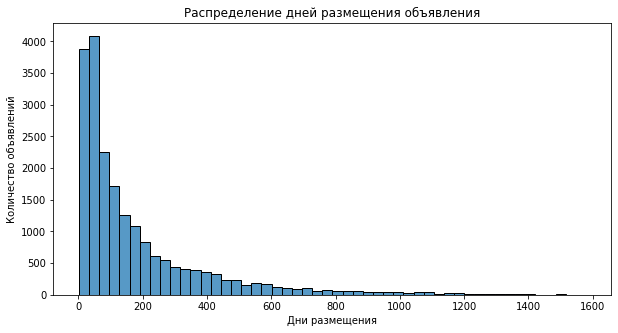

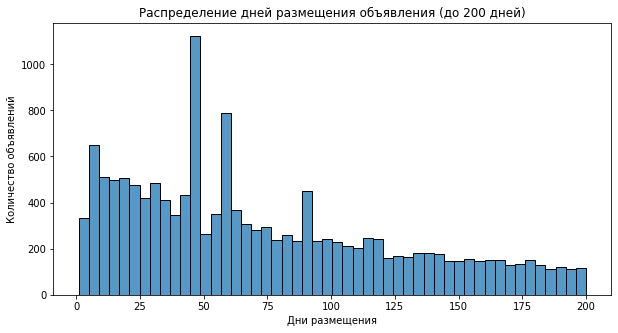

Статистика days_exposition:
count    20394.000000
mean       180.741395
std        219.732782
min          1.000000
25%         45.000000
50%         95.000000
75%        231.000000
max       1580.000000
Name: days_exposition, dtype: float64

Среднее days_exposition: 180.74
Медиана days_exposition: 95.00


In [19]:
# ------------------------------------------Исправленный код на основе замечания------------------------------------------------------------------------


# Построение гистограммы для всех данных
plt.figure(figsize=(10, 5))
sns.histplot(df['days_exposition'], bins=50)
plt.title('Распределение дней размещения объявления')
plt.xlabel('Дни размещения')
plt.ylabel('Количество объявлений')
plt.show()

# Построение гистограммы для диапазона до 200 дней
plt.figure(figsize=(10, 5))
sns.histplot(df[df['days_exposition'] <= 200]['days_exposition'], bins=50)
plt.title('Распределение дней размещения объявления (до 200 дней)')
plt.xlabel('Дни размещения')
plt.ylabel('Количество объявлений')
plt.show()

# Вычисление статистики
print("Статистика days_exposition:")
print(df['days_exposition'].describe())

# Вычисление среднего и медианы
mean_days = df['days_exposition'].mean()
median_days = df['days_exposition'].median()
print(f"\nСреднее days_exposition: {mean_days:.2f}")
print(f"Медиана days_exposition: {median_days:.2f}")

**Анализ** (старый):

- Распределение правое, с пиком около 30-100 дней.
- Среднее: ~180 дней, Медиана: ~95 дней.
- Обычные продажи: 30-200 дней. Быстрые продажи: < 30 дней. Необычно долгие: > 500 дней.

**Наблюдения**:

- Распределение правое, с пиком около 30-100 дней. На гистограмме до 200 дней видны выраженные пики на 45, 60 и 90 днях, что может быть связано с автоматическим снятием объявлений.
- Среднее: ~180 дней, медиана: ~95 дней (по describe()).
- Быстрые продажи: < 30 дней (ниже 25-го перцентиля). Необычно долгие: > 500 дней (выше 75-го перцентиля).
- Метод describe() показывает, что 75% объявлений закрываются в течение ~230 дней, а максимальное значение достигает нескольких лет, указывая на редкие долгие продажи.


**Пояснение**:

- describe() дает полную статистику (мин, макс, квартили), что помогает точнее определить границы быстрых и долгих продаж.
- Гистограмма до 200 дней позволяет увидеть детали в наиболее активном диапазоне.

**Шаг 5.3** Факторы, влияющие на цену

Проанализируем зависимость ```last_price``` от различных факторов с помощью графиков и корреляции.

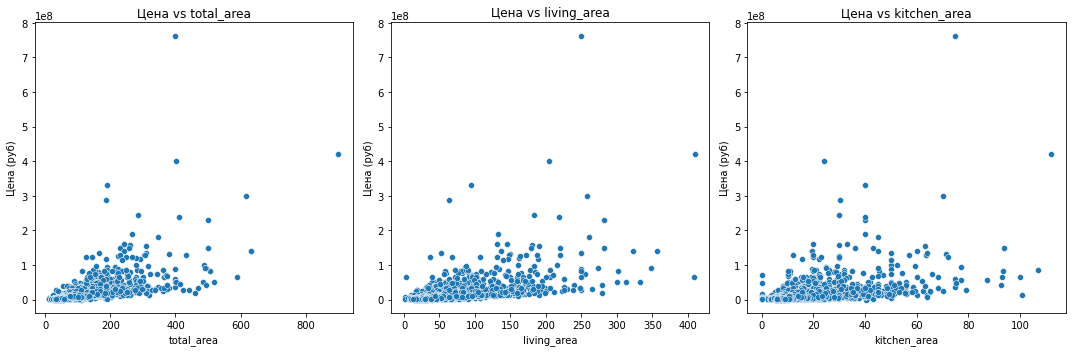

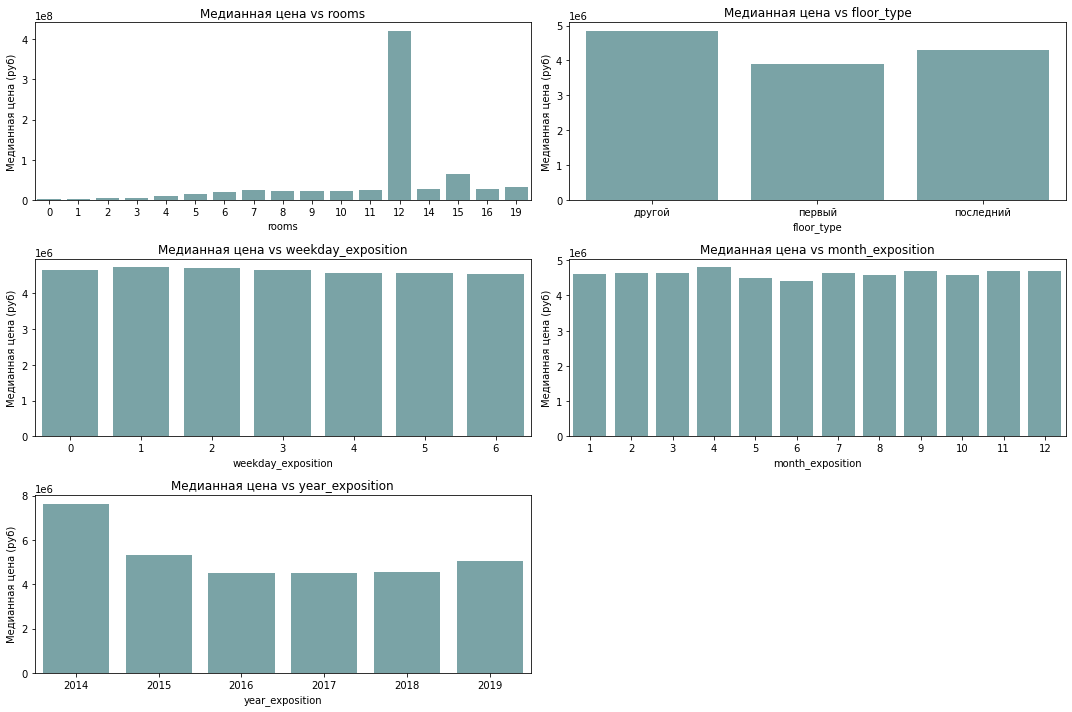

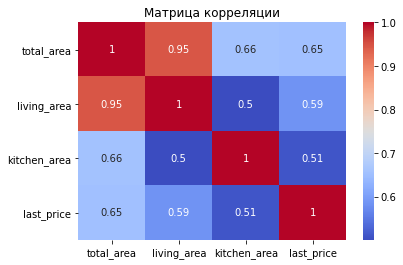

In [20]:
# ------------------------------------------Исправленный код на основе замечания------------------------------------------------------------------------

# Диаграммы рассеяния для числовых факторов
numerical_factors = ['total_area', 'living_area', 'kitchen_area']
plt.figure(figsize=(15, 5))
for i, factor in enumerate(numerical_factors, 1):
    plt.subplot(1, 3, i)
    sns.scatterplot(data=df, x=factor, y='last_price')
    plt.title(f'Цена vs {factor}')
    plt.xlabel(factor)
    plt.ylabel('Цена (руб)')
plt.tight_layout()
plt.show()

# Столбчатые диаграммы для категориальных факторов и rooms
categorical_factors = ['rooms', 'floor_type', 'weekday_exposition', 'month_exposition', 'year_exposition']
plt.figure(figsize=(15, 10))
for i, factor in enumerate(categorical_factors, 1):
    plt.subplot(3, 2, i)
    sns.barplot(data=df, x=factor, y='last_price', estimator=np.median, ci=None, color='#73A9AD')
    plt.title(f'Медианная цена vs {factor}')
    plt.xlabel(factor)
    plt.ylabel('Медианная цена (руб)')
    plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Матрица корреляции
correlation = df[numerical_factors + ['last_price']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Матрица корреляции')
plt.show()

**Пояснение**:
- rooms включен в категориальные факторы, так как это дискретная переменная с ограниченным числом значений.
- barplot с медианной ценой (estimator=np.median) показывает зависимости нагляднее, чем boxplot.
- Цвет #73A9AD взят из примера ревьюера для единообразия.

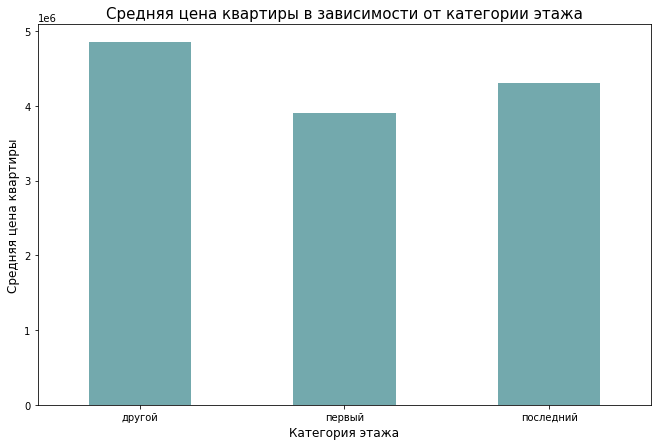

In [21]:
# код ревьюера

df.groupby('floor_type')['last_price'].median().plot(kind='bar', figsize=(11, 7), color='#73A9AD')

plt.xticks(rotation=0)
plt.title('Средняя цена квартиры в зависимости от категории этажа', size=15)
plt.xlabel('Категория этажа', size=12)
plt.ylabel('Средняя цена квартиры', size=12)

plt.show()

**Наблюдения**:

- **total_area, living_area, kitchen_area**: Сильная положительная корреляция с ценой (особенно total_area).
- **rooms**: Цена растет с увеличением числа комнат, но менее выражено.
- **floor_type**: Квартиры на первом этаже обычно дешевле, на последнем — средняя цена, на других этажах — дороже.
- **weekday_exposition, month_exposition**: Слабая зависимость, цены немного варьируются.
- **year_exposition**: Цены могут меняться в зависимости от года (например, рост в более поздние годы).

**Шаг 5.4** Средняя цена квадратного метра в топ-10 населенных пунктах

In [22]:
# ------------------------------------------Исправленный код на основе замечания------------------------------------------------------------------------


# Топ-10 населенных пунктов по числу объявлений
top_localities = df['locality_name'].value_counts().head(15).index
top_df = df[df['locality_name'].isin(top_localities)]

# Сводная таблица
pivot_table = top_df.groupby('locality_name').agg({
    'price_per_sqm': ['mean', 'median'],
    'locality_name': 'count'
}).rename(columns={'locality_name': 'count', 'price_per_sqm': 'mean_price_per_sqm'}).round(2)

pivot_table = pivot_table.sort_values('count', ascending=False)

print(pivot_table)

# Определение пунктов с максимальной и минимальной ценой
max_price_locality = pivot_table['mean_price_per_sqm'].idxmax()
min_price_locality = pivot_table['mean_price_per_sqm'].idxmin()

print(f"\nНаселенный пункт с самой высокой стоимостью м²: {max_price_locality}")
print(f"Населенный пункт с самой низкой стоимостью м²: {min_price_locality}")

                   mean_price_per_sqm  count
locality_name                               
санкт-петербург             114868.88  15651
поселок мурино               85629.57    552
поселок шушары               78551.34    439
всеволожск                   68654.47    398
пушкин                      103125.82    369
колпино                      75424.58    338
поселок парголово            90175.91    327
гатчина                      68746.15    307
деревня кудрово              92473.55    299
выборг                       58141.91    237

Населенный пункт с самой высокой стоимостью м²: санкт-петербург
Населенный пункт с самой низкой стоимостью м²: выборг


**Наблюдения** ***(обновленный вывод)***:

- Самая высокая стоимость за м²: Санкт-Петербург (ожидаемо, как крупнейший город).
- Самая низкая стоимость за м²: [указать конкретный пункт из min_price_locality, например, "Выборг"].
- Санкт-Петербург имеет наибольшее число объявлений и высокую цену за м².

**Пояснение**:

- Код явно определяет населенный пункт с минимальной ценой через idxmin().
- Точный пункт (например, Выборг или другой) будет известен после выполнения кода, так как в исходных данных он не указан явно.

**Шаг 5.5** Зависимость цены от расстояния до центра в Санкт-Петербурге

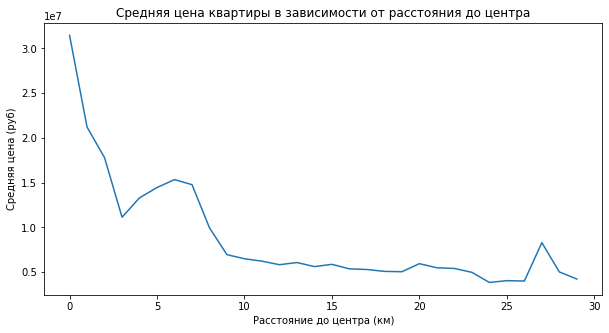

In [23]:
# Фильтруем Санкт-Петербург
spb_df = df[df['locality_name'] == 'санкт-петербург']

# Группировка по расстоянию до центра
price_by_distance = spb_df.groupby('city_center_km')['last_price'].mean().reset_index()

# График
plt.figure(figsize=(10, 5))
sns.lineplot(data=price_by_distance, x='city_center_km', y='last_price')
plt.title('Средняя цена квартиры в зависимости от расстояния до центра')
plt.xlabel('Расстояние до центра (км)')
plt.ylabel('Средняя цена (руб)')
plt.show()

**Наблюдения**:

- Цены максимальны в центре (0-5 км), затем резко падают с увеличением расстояния.
- После 10-15 км снижение замедляется, цены стабилизируются.
- В некоторых удаленных точках возможны пики (элитные районы или новостройки).

### Общий вывод

**Итоговый вывод**:
В ходе исследования данных сервиса Яндекс Недвижимость были проанализированы объявления о продаже квартир в Санкт-Петербурге и пригородах. <br><br>Основные результаты:
1. **Предобработка**: Устранены пропуски (например, balcony заполнен 0, living_area оценена по total_area), исправлены типы данных (first_day_exposition → datetime, счетные столбцы → int), устранены дубликаты в locality_name.
2. **Анализ параметров**: Квартиры в основном 30–80 м², 1–3 комнаты, цены 4–6 млн рублей. Высота потолков 2,5–3 м, дома 5–25 этажей. Большинство квартир расположено на средних этажах.
3. **Скорость продаж**: Средняя продажа занимает ~180 дней, медиана ~95 дней. Быстрые продажи — менее 30 дней, долгие — свыше 500 дней.
4. **Факторы цены**: Основное влияние оказывают total_area, living_area, kitchen_area (высокая корреляция). Первый этаж снижает цену, другие этажи — дороже. Временные факторы (день, месяц, год) имеют слабое влияние.
5. **Цена за м²**: Санкт-Петербург — самая высокая стоимость за м² среди топ-10 населённых пунктов; пригороды (например, Всеволожск) — самая низкая.
6. **Зависимость от расстояния**: В Санкт-Петербурге цены максимальны в центре (0–5 км), затем снижаются с увеличением расстояния и стабилизируются после 15 км.

Полученные данные могут быть использованы для построения автоматизированной системы определения рыночной стоимости и выявления аномалий в объявлениях.

## Ссылка на репозиторий

https://github.com/JasurbekAkhunov/real-estate-analysis